# XGBoost pool model (same features as LightGBM)
Global XGBoost with same features as 05-lightgbm-pool: **VIX 5-day SMA**, **Fear & Greed change** (lag1 − lag5), month_sin, month_cos.

In [1]:
import sys
from pathlib import Path
from datetime import datetime, timezone, timedelta
import numpy as np
import pandas as pd
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

REPO_ROOT = Path.cwd().parent.parent
BACKEND_DIR = REPO_ROOT / "backend"
sys.path.insert(0, str(BACKEND_DIR))
sys.path.insert(0, str(Path.cwd()))

from _pool_common import (
    load_pool_data,
    build_pooled_train_stack,
    compute_metrics_averaged_over_windows,
    metrics_to_parquet,
    TEST_SIZE,
    FORECAST_HORIZON,
    ROLLING_STEP,
    MIN_TRAIN_STACK,
    ARTIFACTS_DIR,
    TICKERS,
)

XGB_PARAMS = dict(n_estimators=100, max_depth=4, learning_rate=0.01, random_state=42)


def fetch_cnn_fear_greed_index(limit_days=500, start_date=None):
    """Fetch CNN Fear & Greed Index from production.dataviz.cnn.io."""
    if start_date is not None:
        start_date = pd.to_datetime(start_date).strftime("%Y-%m-%d")
    else:
        start_date = (datetime.now(timezone.utc) - timedelta(days=limit_days)).strftime("%Y-%m-%d")
    url = f"https://production.dataviz.cnn.io/index/fearandgreed/graphdata/{start_date}"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
        "Accept": "application/json",
        "Referer": "https://www.cnn.com/markets/fear-and-greed",
        "Origin": "https://www.cnn.com",
    }
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code != 200:
            return pd.DataFrame(columns=["timestamp", "fear_greed"])
        data = response.json()
        fng_data = data.get("fear_and_greed_historical", {}).get("data") or []
        if not fng_data:
            return pd.DataFrame(columns=["timestamp", "fear_greed"])
        fng_df = pd.DataFrame(fng_data)
        fng_df["timestamp"] = pd.to_datetime(fng_df["x"] / 1000, unit="s").dt.normalize()
        fng_df = fng_df.rename(columns={"y": "fear_greed"})
        return fng_df[["timestamp", "fear_greed"]].drop_duplicates("timestamp").sort_values("timestamp")
    except Exception:
        return pd.DataFrame(columns=["timestamp", "fear_greed"])

In [2]:
def build_feature_df(grp: pd.DataFrame):
    """Same features as LightGBM (05): VIX 5-day SMA, Fear & Greed change (lag1 - lag5), month sin/cos. Target = next 21 returns."""
    df = grp.sort_values("timestamp").copy()
    df["close"] = df["close"].astype(float)
    df["return"] = df["close"].pct_change()
    if "vix" in df.columns:
        df["vix_sma_5"] = df["vix"].astype(float).shift(1).rolling(5).mean()
    else:
        df["vix_sma_5"] = np.nan
    df["month"] = pd.to_datetime(df["timestamp"]).dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    if "fear_greed" not in df.columns:
        df["fear_greed"] = 50.0
    else:
        df["fear_greed"] = df["fear_greed"].fillna(50.0)
    df["fear_greed_lag_1"] = df["fear_greed"].shift(1)
    df["fear_greed_lag_5"] = df["fear_greed"].shift(5)
    df["fear_greed_change"] = df["fear_greed_lag_1"] - df["fear_greed_lag_5"]
    for h in range(1, FORECAST_HORIZON + 1):
        df[f"target_{h}"] = df["return"].shift(-h)
    feature_cols = ["vix_sma_5", "month_sin", "month_cos", "fear_greed_change"]
    target_cols = [f"target_{h}" for h in range(1, FORECAST_HORIZON + 1)]
    base_cols = ["timestamp", "close", "return"] + feature_cols + target_cols
    out = df[[c for c in base_cols if c in df.columns]].copy()
    return out.dropna(), feature_cols, target_cols


def train_global_xgb(stacked: pd.DataFrame, horizon: int):
    """Train one XGBoost on pooled data (all assets, rows before 60-day test window). Returns dict for predict_xgb_global."""
    pooled = build_pooled_train_stack(stacked, TEST_SIZE, MIN_TRAIN_STACK)
    if pooled.empty:
        return None
    feat_dfs = []
    for sym in pooled["symbol"].unique():
        grp = pooled[pooled["symbol"] == sym].copy()
        try:
            feat_df, feature_cols, target_cols = build_feature_df(grp)
        except Exception:
            continue
        if len(feat_df) < MIN_TRAIN_STACK + horizon:
            continue
        feat_dfs.append(feat_df)
    if not feat_dfs:
        return None
    pooled_feat = pd.concat(feat_dfs, ignore_index=True)
    X = pooled_feat[feature_cols].values.astype(np.float32)
    y = pooled_feat[target_cols].values.astype(np.float32)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    xgb_multi = MultiOutputRegressor(XGBRegressor(**XGB_PARAMS))
    xgb_multi.fit(X_s, y)
    return {"model": xgb_multi, "scaler": scaler, "feature_cols": feature_cols}


def predict_xgb_global(context_df: pd.DataFrame, horizon: int, global_xgb: dict) -> list:
    """Predict 21 price steps using pre-trained global XGBoost."""
    if global_xgb is None:
        return []
    try:
        feat_df, feature_cols, _ = build_feature_df(context_df)
    except Exception:
        return []
    if len(feat_df) < 1:
        return []
    X = feat_df[feature_cols].values.astype(np.float32)
    X_s = global_xgb["scaler"].transform(X)
    last_row = X_s[-1:]
    pred_returns = global_xgb["model"].predict(last_row).ravel()
    p0 = float(context_df["close"].iloc[-1])
    prices = p0 * np.cumprod(np.concatenate([[1.0], 1.0 + pred_returns]))[1:]
    return [float(p) for p in prices[:horizon]]

In [3]:
stacked = load_pool_data(with_vix=True, with_volume=True)
symbol_start = pd.to_datetime(stacked["timestamp"]).min().strftime("%Y-%m-%d")
fear_greed_df = fetch_cnn_fear_greed_index(start_date=symbol_start)
if not fear_greed_df.empty:
    stacked["date"] = pd.to_datetime(stacked["timestamp"]).dt.normalize()
    fear_greed_df["date"] = pd.to_datetime(fear_greed_df["timestamp"]).dt.normalize()
    stacked = stacked.merge(fear_greed_df[["date", "fear_greed"]], on="date", how="left")
    stacked["fear_greed"] = stacked["fear_greed"].ffill().bfill()
    stacked = stacked.drop(columns=["date"])
print(stacked.groupby("symbol").size())
stacked.head(10)

symbol
AAPL     1256
AMZN     1256
GOOGL    1256
JNJ      1256
JPM      1256
MSFT     1256
NVDA     1256
SPY      1256
WMT      1256
XOM      1256
dtype: int64


,timestamp,symbol,close,volume,vix,fear_greed
0,2021-03-08,AAPL,116.360001,154376600,25.469999,39.080000
1,2021-03-09,AAPL,121.089996,129525800,24.030001,43.360000
2,2021-03-10,AAPL,119.980003,111943300,22.559999,45.560000
3,2021-03-11,AAPL,121.959999,103026500,21.910000,50.480000
4,2021-03-12,AAPL,121.029999,88105100,20.690001,53.720000
5,2021-03-15,AAPL,123.989998,92403800,20.030001,56.520000
6,2021-03-16,AAPL,125.570000,115227900,19.790001,54.800000
7,2021-03-17,AAPL,124.760002,111932600,19.230000,57.866667
8,2021-03-18,AAPL,120.529999,121229700,21.580000,52.333333
9,2021-03-19,AAPL,119.989998,185549500,20.950001,50.833333


In [4]:
# Train once on pooled data (all assets, only rows before 60-day test window)
global_xgb = train_global_xgb(stacked, FORECAST_HORIZON)
print("Global XGBoost (LGB features) trained on", len(build_pooled_train_stack(stacked, TEST_SIZE, MIN_TRAIN_STACK)), "pooled train rows.")

Global XGBoost (LGB features) trained on 11960 pooled train rows.


In [5]:
model_name = "xgboost_lgb_feats"
all_preds = []
for sym in TICKERS:
    grp = stacked[stacked["symbol"] == sym].copy()
    if grp.empty:
        continue
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    prices = grp.set_index("timestamp")["close"].astype(float).dropna()
    n = len(prices)
    if n < TEST_SIZE + MIN_TRAIN_STACK:
        continue
    split_idx = n - TEST_SIZE
    test_index = prices.index[split_idx:]
    test_values = prices.values[split_idx:]
    preds = []
    window_ix = 0
    start = 0
    while start + FORECAST_HORIZON <= TEST_SIZE:
        context_cols = ["timestamp", "close", "vix"] + [c for c in ["volume", "fear_greed"] if c in grp.columns]
        context_df = grp.iloc[: split_idx + start][context_cols].copy()
        if len(context_df) < MIN_TRAIN_STACK:
            start += ROLLING_STEP
            continue
        price_list = predict_xgb_global(context_df, FORECAST_HORIZON, global_xgb)
        if not price_list or len(price_list) < FORECAST_HORIZON:
            start += ROLLING_STEP
            window_ix += 1
            continue
        for h in range(FORECAST_HORIZON):
            idx = start + h
            ts = test_index[idx]
            y_true = float(test_values[idx])
            y_pred = float(price_list[h])
            preds.append({"timestamp": ts, "y_true": y_true, "y_pred": y_pred, "window_ix": window_ix})
        window_ix += 1
        start += ROLLING_STEP
    if preds:
        pred_df = pd.DataFrame(preds)
        pred_df["symbol"] = sym
        all_preds.append(pred_df)

pred_xgb = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame(
    columns=["timestamp", "y_true", "y_pred", "window_ix", "symbol"]
)
print(pred_xgb.groupby("symbol").size() if not pred_xgb.empty else "No predictions.")
pred_xgb.head()

symbol
AAPL     126
AMZN     126
GOOGL    126
JNJ      126
JPM      126
MSFT     126
NVDA     126
SPY      126
WMT      126
XOM      126
dtype: int64


,timestamp,y_true,y_pred,window_ix,symbol
0,2025-12-09,277.179993,278.304368,0,AAPL
1,2025-12-10,278.779999,278.484350,0,AAPL
2,2025-12-11,278.029999,278.668034,0,AAPL
3,2025-12-12,278.279999,278.820480,0,AAPL
4,2025-12-15,274.109985,278.994581,0,AAPL


XGBoost feature importance (avg over 21 horizons, global model):
          feature  importance
        vix_sma_5    0.273031
fear_greed_change    0.260398
        month_sin    0.252827
        month_cos    0.213744


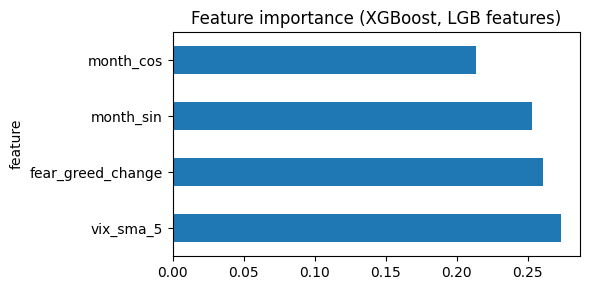

In [7]:
# Feature importance (average across 21 horizon-specific XGB estimators from global model)
import matplotlib.pyplot as plt
if global_xgb is not None:
    feature_cols = global_xgb["feature_cols"]
    xgb_multi = global_xgb["model"]
    imp = np.mean([est.feature_importances_ for est in xgb_multi.estimators_], axis=0)
    fi_df = pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values("importance", ascending=False)
    print("XGBoost feature importance (avg over 21 horizons, global model):")
    print(fi_df.to_string(index=False))
    fi_df.plot(x="feature", y="importance", kind="barh", legend=False, figsize=(6, 3))
    plt.title("Feature importance (XGBoost, LGB features)")
    plt.tight_layout()
    plt.show()
else:
    print("Run the train cell first to get global_xgb.")

In [6]:
metrics_rows = []
for sym in pred_xgb["symbol"].unique():
    sub = pred_xgb[pred_xgb["symbol"] == sym]
    m = compute_metrics_averaged_over_windows(sub)
    metrics_rows.append({"model": model_name, "symbol": sym, **m})
m_overall = compute_metrics_averaged_over_windows(pred_xgb)
metrics_rows.append({"model": model_name, "symbol": "overall", **m_overall})

metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.to_string())
metrics_to_parquet(metrics_rows, ARTIFACTS_DIR / "metrics_xgboost_lgb_feats_pool.parquet")
print("Saved:", ARTIFACTS_DIR / "metrics_xgboost_lgb_feats_pool.parquet")

                model   symbol        MAE       RMSE    MAPE_%
0   xgboost_lgb_feats     AAPL  11.057782  13.415262  4.204364
1   xgboost_lgb_feats     MSFT  26.881084  31.297895  6.295452
2   xgboost_lgb_feats    GOOGL  13.084089  14.876072  4.099062
3   xgboost_lgb_feats     AMZN  13.722230  16.143974  6.285800
4   xgboost_lgb_feats      JPM  10.927446  12.789047  3.520581
5   xgboost_lgb_feats      JNJ   9.456504  10.782912  4.130600
6   xgboost_lgb_feats      WMT   4.880260   5.619047  3.963417
7   xgboost_lgb_feats      SPY   8.343800   9.595479  1.214580
8   xgboost_lgb_feats      XOM   7.491805   8.755607  5.361200
9   xgboost_lgb_feats     NVDA   6.762820   8.065500  3.677881
10  xgboost_lgb_feats  overall  11.260782  15.557083  4.275294
Saved: C:\capstone_project_unfc\model\experiments-pool\artifacts\metrics_xgboost_lgb_feats_pool.parquet
